# SHAP Explainability

This notebook explores model interpretability using SHAP (SHapley Additive exPlanations).

The objective is to understand which borrower characteristics contribute most strongly to predicted default risk in the Random Forest model.

SHAP provides both global explanations and individual prediction explanations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

## Load Engineered Dataset

Load the feature-engineered borrower dataset prepared in Notebook 02.

In [2]:
credit = pd.read_csv(
    "/Users/Mandy/Desktop/GithubProjects/credit-risk-prediction/data/credit_risk_engineered.csv"
)

credit.shape

(31521, 24)

In [3]:
features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "loan_grade_encoded",
    "default_history_encoded",
    "income_to_loan_ratio",
    "credit_history_ratio",
    "employment_stability",
    "interest_burden"
]

X = credit[features]

y = credit["loan_status"]

X.shape

(31521, 13)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training complete.")

Random Forest training complete.


In [5]:
import numba
import shap

print("numba version:", numba.__version__)
print("shap version:", shap.__version__)
print("SHAP imported successfully.")

numba version: 0.58.1
shap version: 0.44.1
SHAP imported successfully.


# SHAP Explainability

Use SHAP values to understand how individual features influence borrower default predictions.

SHAP provides local and global explanations for machine learning models.

In [6]:
import shap

explainer = shap.TreeExplainer(
    rf_model
)

print("SHAP explainer created.")

SHAP explainer created.


In [7]:
# Calculate SHAP values on a sample

X_test_sample = X_test.sample(
    n=300,
    random_state=42
)

shap_values = explainer.shap_values(
    X_test_sample
)

print("SHAP values calculated.")

SHAP values calculated.


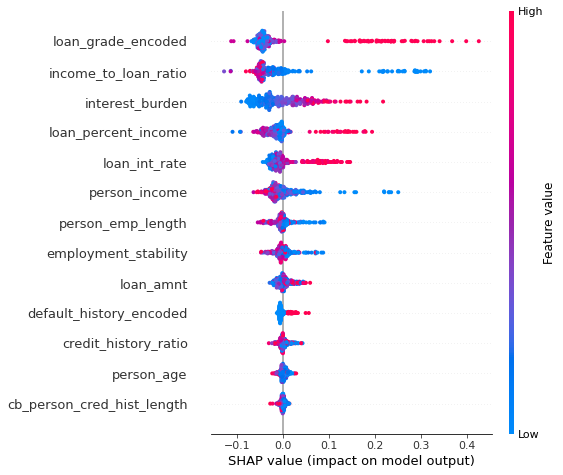

In [8]:
# SHAP summary plot for default prediction

shap.summary_plot(
    shap_values[1],
    X_test_sample,
    feature_names=X_test_sample.columns
)

## SHAP Findings

SHAP analysis confirms that loan grade remains the strongest predictor of borrower default.

Among engineered features, income_to_loan_ratio, interest_burden, and loan_percent_income contribute significantly to model predictions.

Borrowers with larger loan burdens relative to income are more likely to default, while higher income-to-loan ratios generally reduce default risk.

The SHAP results validate the effectiveness of the feature engineering process and provide interpretable explanations for Random Forest predictions.